In [1]:
# new file

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# ============================================================
# LOAD FINAL ECONOMIC MASTER DATASET
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "final_economic_master.csv"
)

df = pd.read_csv(
    DATA_FILE,
    parse_dates=["date"]
)

df = df.sort_values("date").reset_index(drop=True)

print("=" * 60)
print("FINAL ECONOMIC MASTER DATASET")
print("=" * 60)

print("\nShape:", df.shape)

print("\nDate range:")
print(
    df["date"].min().strftime("%Y-%m-%d"),
    "→",
    df["date"].max().strftime("%Y-%m-%d")
)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

FINAL ECONOMIC MASTER DATASET

Shape: (163, 15)

Date range:
2013-01-01 → 2026-07-01

Columns:
['date', 'year', 'month', 'cpi_index', 'inflation', 'wpi_inflation', 'repo_rate', 'brent_price_usd', 'brent_mom_change_pct', 'brent_yoy_change_pct', 'usd_inr_rate', 'usd_inr_mom_change_pct', 'usd_inr_yoy_change_pct', 'food_beverages_index', 'food_beverages_inflation']

Missing values:
date                         0
year                         0
month                        0
cpi_index                    0
inflation                   12
wpi_inflation                3
repo_rate                    0
brent_price_usd              0
brent_mom_change_pct         1
brent_yoy_change_pct        12
usd_inr_rate                 0
usd_inr_mom_change_pct       1
usd_inr_yoy_change_pct      12
food_beverages_index         7
food_beverages_inflation    21
dtype: int64

First 5 rows:


,date,year,month,cpi_index,inflation,wpi_inflation,repo_rate,brent_price_usd,brent_mom_change_pct,brent_yoy_change_pct,usd_inr_rate,usd_inr_mom_change_pct,usd_inr_yoy_change_pct,food_beverages_index,food_beverages_inflation
0,2013-01-01,2013,January,55.1,NaN,NaN,7.75,113.0,NaN,NaN,54.2290,NaN,NaN,105.6,NaN
1,2013-02-01,2013,February,55.5,NaN,NaN,7.75,116.5,3.097345,NaN,53.8079,-0.776522,NaN,106.6,NaN
2,2013-03-01,2013,March,55.6,NaN,NaN,7.50,109.2,-6.266094,NaN,54.4229,1.142955,NaN,106.9,NaN
3,2013-04-01,2013,April,55.9,NaN,3.724928,7.50,102.9,-5.769231,NaN,54.3236,-0.182460,NaN,107.7,NaN
4,2013-05-01,2013,May,56.3,NaN,3.133903,7.25,103.0,0.097182,NaN,54.9845,1.216598,NaN,109.2,NaN



Last 5 rows:


,date,year,month,cpi_index,inflation,wpi_inflation,repo_rate,brent_price_usd,brent_mom_change_pct,brent_yoy_change_pct,usd_inr_rate,usd_inr_mom_change_pct,usd_inr_yoy_change_pct,food_beverages_index,food_beverages_inflation
158,2026-03-01,2026,March,104.84,3.402702,3.976143,5.25,103.7,45.850914,42.837466,92.8182,2.283742,7.277737,NaN,NaN
159,2026-04-01,2026,April,105.12,3.484938,8.358209,5.25,120.4,16.104147,77.843427,93.4805,0.713545,9.235798,NaN,NaN
160,2026-05-01,2026,May,105.91,3.935231,9.880240,5.25,107.5,-10.714286,67.445483,95.5335,2.196180,12.067752,NaN,NaN
161,2026-06-01,2026,June,107.00,4.380060,9.870389,5.25,85.4,-20.558140,19.440559,94.9600,-0.600313,10.577399,NaN,NaN
162,2026-07-01,2026,July,107.94,4.441219,9.780439,5.25,83.4,-2.341920,17.464789,95.8573,0.944924,11.240272,NaN,NaN


In [3]:
# ============================================================
# INSPECT TARGET VARIABLE: CPI INFLATION
# ============================================================

target = "inflation"

print("=" * 60)
print("CPI INFLATION TARGET INSPECTION")
print("=" * 60)

print("\nSummary statistics:")
print(df[target].describe())

print("\nMissing inflation observations:")
print(df[target].isna().sum())

print("\nFirst valid inflation date:")
print(
    df.loc[df[target].notna(), "date"].min()
)

print("\nLatest inflation date:")
print(
    df.loc[df[target].notna(), "date"].max()
)

CPI INFLATION TARGET INSPECTION

Summary statistics:
count    151.000000
mean       4.847992
std        1.690722
min        0.038573
25%        3.640000
50%        4.880000
75%        5.860000
max        8.600000
Name: inflation, dtype: float64

Missing inflation observations:
12

First valid inflation date:
2014-01-01 00:00:00

Latest inflation date:
2026-07-01 00:00:00


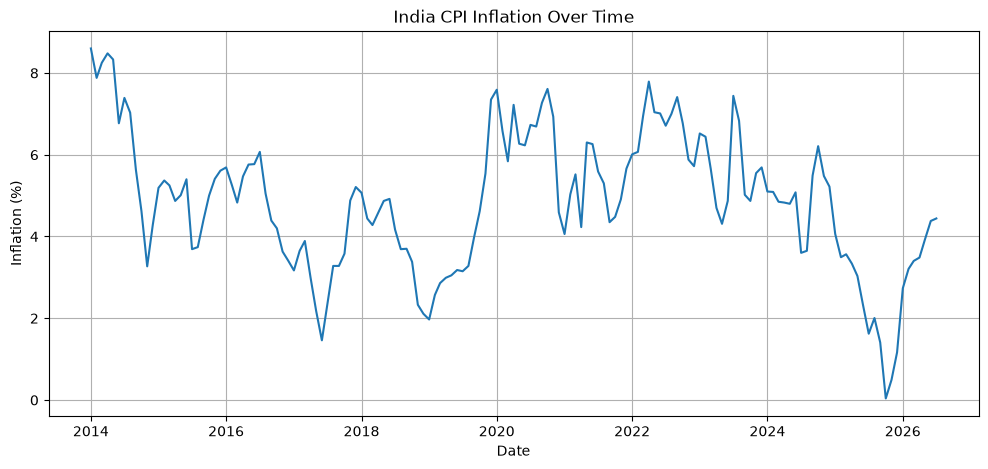

In [4]:
# ============================================================
# CPI INFLATION OVER TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["inflation"]
)

plt.title("India CPI Inflation Over Time")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.grid(True)
plt.show()

In [5]:
# ============================================================
# CREATE NEXT-MONTH INFLATION TARGET
# ============================================================

model_df = df.copy()

# Inflation one month into the future
model_df["target_next_month_inflation"] = (
    model_df["inflation"].shift(-1)
)

print("=" * 60)
print("NEXT-MONTH FORECASTING TARGET")
print("=" * 60)

print("\nFirst observations:")

display(
    model_df[
        [
            "date",
            "inflation",
            "target_next_month_inflation"
        ]
    ].head(20)
)

print("\nLast observations:")

display(
    model_df[
        [
            "date",
            "inflation",
            "target_next_month_inflation"
        ]
    ].tail(10)
)

NEXT-MONTH FORECASTING TARGET

First observations:


,date,inflation,target_next_month_inflation
0,2013-01-01,NaN,NaN
1,2013-02-01,NaN,NaN
2,2013-03-01,NaN,NaN
3,2013-04-01,NaN,NaN
4,2013-05-01,NaN,NaN
5,2013-06-01,NaN,NaN
6,2013-07-01,NaN,NaN
7,2013-08-01,NaN,NaN
8,2013-09-01,NaN,NaN
9,2013-10-01,NaN,NaN



Last observations:


,date,inflation,target_next_month_inflation
153,2025-10-01,0.038573,0.492754
154,2025-11-01,0.492754,1.166181
155,2025-12-01,1.166181,2.734337
156,2026-01-01,2.734337,3.207659
157,2026-02-01,3.207659,3.402702
158,2026-03-01,3.402702,3.484938
159,2026-04-01,3.484938,3.935231
160,2026-05-01,3.935231,4.380060
161,2026-06-01,4.380060,4.441219
162,2026-07-01,4.441219,NaN


In [6]:
# ============================================================
# CREATE LAG FEATURES
# ============================================================

# Previous CPI inflation values
for lag in [1, 2, 3, 6, 12]:
    model_df[f"inflation_lag_{lag}"] = (
        model_df["inflation"].shift(lag)
    )


# Previous WPI inflation values
for lag in [1, 3]:
    model_df[f"wpi_inflation_lag_{lag}"] = (
        model_df["wpi_inflation"].shift(lag)
    )


# Previous crude oil prices
for lag in [1, 3]:
    model_df[f"brent_price_lag_{lag}"] = (
        model_df["brent_price_usd"].shift(lag)
    )


# Previous USD/INR exchange rates
for lag in [1, 3]:
    model_df[f"usd_inr_rate_lag_{lag}"] = (
        model_df["usd_inr_rate"].shift(lag)
    )


# Previous repo rate
model_df["repo_rate_lag_1"] = (
    model_df["repo_rate"].shift(1)
)


print("=" * 60)
print("LAG FEATURES CREATED")
print("=" * 60)

lag_columns = [
    column
    for column in model_df.columns
    if "lag" in column
]

print("\nLag features:")
print(lag_columns)

print("\nNumber of lag features:", len(lag_columns))

display(
    model_df[
        [
            "date",
            "inflation",
            "inflation_lag_1",
            "inflation_lag_3",
            "inflation_lag_12",
            "target_next_month_inflation"
        ]
    ].tail(15)
)

LAG FEATURES CREATED

Lag features:
['inflation_lag_1', 'inflation_lag_2', 'inflation_lag_3', 'inflation_lag_6', 'inflation_lag_12', 'wpi_inflation_lag_1', 'wpi_inflation_lag_3', 'brent_price_lag_1', 'brent_price_lag_3', 'usd_inr_rate_lag_1', 'usd_inr_rate_lag_3', 'repo_rate_lag_1']

Number of lag features: 12


,date,inflation,inflation_lag_1,inflation_lag_3,inflation_lag_12,target_next_month_inflation
148,2025-05-01,3.033367,3.336724,3.493361,4.800000,2.305389
149,2025-06-01,2.305389,3.033367,3.564862,5.080000,1.622419
150,2025-07-01,1.622419,2.305389,3.336724,3.600000,2.005900
151,2025-08-01,2.005900,1.622419,3.033367,3.650000,1.407625
152,2025-09-01,1.407625,2.005900,2.305389,5.490000,0.038573
153,2025-10-01,0.038573,1.407625,1.622419,6.210000,0.492754
154,2025-11-01,0.492754,0.038573,2.005900,5.480000,1.166181
155,2025-12-01,1.166181,0.492754,1.407625,5.220000,2.734337
156,2026-01-01,2.734337,1.166181,0.038573,4.063460,3.207659
157,2026-02-01,3.207659,2.734337,0.492754,3.493361,3.402702


In [7]:
# ============================================================
# CREATE ROLLING FEATURES
# ============================================================

# Rolling averages of inflation
for window in [3, 6, 12]:
    model_df[f"inflation_rolling_mean_{window}"] = (
        model_df["inflation"]
        .rolling(window=window)
        .mean()
    )


# Rolling averages of WPI inflation
for window in [3, 6]:
    model_df[f"wpi_rolling_mean_{window}"] = (
        model_df["wpi_inflation"]
        .rolling(window=window)
        .mean()
    )


# Rolling averages of Brent crude oil price
for window in [3, 6]:
    model_df[f"brent_rolling_mean_{window}"] = (
        model_df["brent_price_usd"]
        .rolling(window=window)
        .mean()
    )


# Rolling averages of USD/INR exchange rate
for window in [3, 6]:
    model_df[f"usd_inr_rolling_mean_{window}"] = (
        model_df["usd_inr_rate"]
        .rolling(window=window)
        .mean()
    )


print("=" * 60)
print("ROLLING FEATURES CREATED")
print("=" * 60)

rolling_columns = [
    column
    for column in model_df.columns
    if "rolling" in column
]

print("\nRolling features:")
print(rolling_columns)

print("\nNumber of rolling features:", len(rolling_columns))

display(
    model_df[
        [
            "date",
            "inflation",
            "inflation_rolling_mean_3",
            "inflation_rolling_mean_6",
            "inflation_rolling_mean_12",
            "target_next_month_inflation"
        ]
    ].tail(15)
)

ROLLING FEATURES CREATED

Rolling features:
['inflation_rolling_mean_3', 'inflation_rolling_mean_6', 'inflation_rolling_mean_12', 'wpi_rolling_mean_3', 'wpi_rolling_mean_6', 'brent_rolling_mean_3', 'brent_rolling_mean_6', 'usd_inr_rolling_mean_3', 'usd_inr_rolling_mean_6']

Number of rolling features: 9


,date,inflation,inflation_rolling_mean_3,inflation_rolling_mean_6,inflation_rolling_mean_12,target_next_month_inflation
148,2025-05-01,3.033367,3.311651,3.785296,4.351814,2.305389
149,2025-06-01,2.305389,2.891827,3.299527,4.120597,1.622419
150,2025-07-01,1.622419,2.320392,2.892687,3.955798,2.005900
151,2025-08-01,2.005900,1.977903,2.644777,3.818790,1.407625
152,2025-09-01,1.407625,1.678648,2.285237,3.478592,0.038573
153,2025-10-01,0.038573,1.150699,1.735545,2.964307,0.492754
154,2025-11-01,0.492754,0.646317,1.312110,2.548703,1.166181
155,2025-12-01,1.166181,0.565836,1.122242,2.210884,2.734337
156,2026-01-01,2.734337,1.464424,1.307561,2.100124,3.207659
157,2026-02-01,3.207659,2.369392,1.507855,2.076316,3.402702


In [8]:
# ============================================================
# CREATE MOMENTUM AND CHANGE FEATURES
# ============================================================

# Inflation momentum
model_df["inflation_change_1m"] = (
    model_df["inflation"].diff(1)
)

model_df["inflation_change_3m"] = (
    model_df["inflation"] -
    model_df["inflation"].shift(3)
)


# WPI momentum
model_df["wpi_change_1m"] = (
    model_df["wpi_inflation"].diff(1)
)


# Brent crude price momentum
model_df["brent_price_change_1m_pct"] = (
    model_df["brent_price_usd"].pct_change(1) * 100
)

model_df["brent_price_change_3m_pct"] = (
    model_df["brent_price_usd"].pct_change(3) * 100
)


# Exchange rate momentum
model_df["usd_inr_change_1m_pct"] = (
    model_df["usd_inr_rate"].pct_change(1) * 100
)

model_df["usd_inr_change_3m_pct"] = (
    model_df["usd_inr_rate"].pct_change(3) * 100
)


# Food & beverages inflation momentum
model_df["food_beverages_change_1m"] = (
    model_df["food_beverages_inflation"].diff(1)
)


print("=" * 60)
print("MOMENTUM AND CHANGE FEATURES CREATED")
print("=" * 60)

momentum_columns = [
    "inflation_change_1m",
    "inflation_change_3m",
    "wpi_change_1m",
    "brent_price_change_1m_pct",
    "brent_price_change_3m_pct",
    "usd_inr_change_1m_pct",
    "usd_inr_change_3m_pct",
    "food_beverages_change_1m"
]

print("\nFeatures created:")
for column in momentum_columns:
    print("-", column)

display(
    model_df[
        [
            "date",
            "inflation",
            "inflation_change_1m",
            "inflation_change_3m",
            "brent_price_change_1m_pct",
            "usd_inr_change_1m_pct",
            "target_next_month_inflation"
        ]
    ].tail(15)
)

MOMENTUM AND CHANGE FEATURES CREATED

Features created:
- inflation_change_1m
- inflation_change_3m
- wpi_change_1m
- brent_price_change_1m_pct
- brent_price_change_3m_pct
- usd_inr_change_1m_pct
- usd_inr_change_3m_pct
- food_beverages_change_1m


,date,inflation,inflation_change_1m,inflation_change_3m,brent_price_change_1m_pct,usd_inr_change_1m_pct,target_next_month_inflation
148,2025-05-01,3.033367,-0.303357,-0.459994,-5.169867,-0.386320,2.305389
149,2025-06-01,2.305389,-0.727978,-1.259473,11.370717,0.739388,1.622419
150,2025-07-01,1.622419,-0.682970,-1.714305,-0.699301,0.343400,2.005900
151,2025-08-01,2.005900,0.383481,-1.027467,-3.943662,1.622464,1.407625
152,2025-09-01,1.407625,-0.598275,-0.897765,-0.293255,0.858632,0.038573
153,2025-10-01,0.038573,-1.369052,-1.583846,-4.852941,0.054007,0.492754
154,2025-11-01,0.492754,0.454181,-1.513146,-1.700155,0.537858,1.166181
155,2025-12-01,1.166181,0.673427,-0.241444,-1.415094,1.340096,2.734337
156,2026-01-01,2.734337,1.568156,2.695764,6.539075,0.963514,3.207659
157,2026-02-01,3.207659,0.473322,2.714905,6.437126,-0.172382,3.402702


In [9]:
# ============================================================
# INSPECT COMPLETE MODELLING DATASET
# ============================================================

print("=" * 60)
print("COMPLETE MODELLING DATASET")
print("=" * 60)

print("\nShape:")
print(model_df.shape)

print("\nAll columns:")
for i, column in enumerate(model_df.columns, start=1):
    print(f"{i}. {column}")

print("\nMissing values:")
print(
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nColumns with missing values:")
missing_cols = model_df.columns[model_df.isna().any()].tolist()

for column in missing_cols:
    print(
        f"{column}: "
        f"{model_df[column].isna().sum()} missing"
    )

COMPLETE MODELLING DATASET

Shape:
(163, 45)

All columns:
1. date
2. year
3. month
4. cpi_index
5. inflation
6. wpi_inflation
7. repo_rate
8. brent_price_usd
9. brent_mom_change_pct
10. brent_yoy_change_pct
11. usd_inr_rate
12. usd_inr_mom_change_pct
13. usd_inr_yoy_change_pct
14. food_beverages_index
15. food_beverages_inflation
16. target_next_month_inflation
17. inflation_lag_1
18. inflation_lag_2
19. inflation_lag_3
20. inflation_lag_6
21. inflation_lag_12
22. wpi_inflation_lag_1
23. wpi_inflation_lag_3
24. brent_price_lag_1
25. brent_price_lag_3
26. usd_inr_rate_lag_1
27. usd_inr_rate_lag_3
28. repo_rate_lag_1
29. inflation_rolling_mean_3
30. inflation_rolling_mean_6
31. inflation_rolling_mean_12
32. wpi_rolling_mean_3
33. wpi_rolling_mean_6
34. brent_rolling_mean_3
35. brent_rolling_mean_6
36. usd_inr_rolling_mean_3
37. usd_inr_rolling_mean_6
38. inflation_change_1m
39. inflation_change_3m
40. wpi_change_1m
41. brent_price_change_1m_pct
42. brent_price_change_3m_pct
43. usd_inr_

In [10]:
# ============================================================
# SELECT FINAL MODEL FEATURES
# ============================================================

target_column = "target_next_month_inflation"

feature_columns = [
    
    # Inflation history
    "inflation",
    "inflation_lag_1",
    "inflation_lag_2",
    "inflation_lag_3",
    "inflation_lag_6",
    "inflation_lag_12",
    "inflation_rolling_mean_3",
    "inflation_rolling_mean_6",
    
    # WPI
    "wpi_inflation",
    "wpi_inflation_lag_1",
    "wpi_inflation_lag_3",
    "wpi_rolling_mean_3",
    
    # Monetary policy
    "repo_rate",
    
    # Crude oil
    "brent_mom_change_pct",
    "brent_yoy_change_pct",
    "brent_price_change_3m_pct",
    "brent_rolling_mean_3",
    
    # Exchange rate
    "usd_inr_mom_change_pct",
    "usd_inr_yoy_change_pct",
    "usd_inr_change_3m_pct",
    "usd_inr_rolling_mean_3"
]

selected_columns = (
    ["date"]
    + feature_columns
    + [target_column]
)

selected_model_df = (
    model_df[selected_columns]
    .copy()
)

print("=" * 60)
print("SELECTED MODELLING DATASET")
print("=" * 60)

print("\nShape:", selected_model_df.shape)

print("\nNumber of features:", len(feature_columns))

print("\nFeatures:")
for i, feature in enumerate(feature_columns, start=1):
    print(f"{i}. {feature}")

print("\nMissing values:")
print(
    selected_model_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

SELECTED MODELLING DATASET

Shape: (163, 23)

Number of features: 21

Features:
1. inflation
2. inflation_lag_1
3. inflation_lag_2
4. inflation_lag_3
5. inflation_lag_6
6. inflation_lag_12
7. inflation_rolling_mean_3
8. inflation_rolling_mean_6
9. wpi_inflation
10. wpi_inflation_lag_1
11. wpi_inflation_lag_3
12. wpi_rolling_mean_3
13. repo_rate
14. brent_mom_change_pct
15. brent_yoy_change_pct
16. brent_price_change_3m_pct
17. brent_rolling_mean_3
18. usd_inr_mom_change_pct
19. usd_inr_yoy_change_pct
20. usd_inr_change_3m_pct
21. usd_inr_rolling_mean_3

Missing values:
inflation_lag_12               24
inflation_lag_6                18
inflation_rolling_mean_6       17
inflation_lag_3                15
inflation_lag_2                14
inflation_rolling_mean_3       14
inflation_lag_1                13
target_next_month_inflation    12
inflation                      12
usd_inr_yoy_change_pct         12
brent_yoy_change_pct           12
wpi_inflation_lag_3             6
wpi_rolling_mean

In [11]:
# ============================================================
# SEPARATE TRAINING DATA AND FUTURE PREDICTION ROW
# ============================================================

# Historical rows where the next month's inflation is known
historical_df = selected_model_df[
    selected_model_df[target_column].notna()
].copy()


# Future row where we want to predict next month's inflation
future_prediction_df = selected_model_df[
    selected_model_df[target_column].isna()
].copy()


print("=" * 60)
print("DATASET SEPARATION")
print("=" * 60)

print("\nHistorical dataset shape:")
print(historical_df.shape)

print("\nHistorical date range:")
print(
    historical_df["date"].min().strftime("%Y-%m-%d"),
    "→",
    historical_df["date"].max().strftime("%Y-%m-%d")
)

print("\nFuture prediction rows:")
print(future_prediction_df.shape)

display(future_prediction_df)

print("\nMissing values in historical data:")
print(
    historical_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

DATASET SEPARATION

Historical dataset shape:
(151, 23)

Historical date range:
2013-12-01 → 2026-06-01

Future prediction rows:
(12, 23)


,date,inflation,inflation_lag_1,inflation_lag_2,inflation_lag_3,inflation_lag_6,inflation_lag_12,inflation_rolling_mean_3,inflation_rolling_mean_6,wpi_inflation,...,repo_rate,brent_mom_change_pct,brent_yoy_change_pct,brent_price_change_3m_pct,brent_rolling_mean_3,usd_inr_mom_change_pct,usd_inr_yoy_change_pct,usd_inr_change_3m_pct,usd_inr_rolling_mean_3,target_next_month_inflation
0,2013-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.75,3.097345,NaN,NaN,NaN,-0.776522,NaN,NaN,NaN,NaN
2,2013-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.50,-6.266094,NaN,NaN,112.900000,1.142955,NaN,NaN,54.153267,NaN
3,2013-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.724928,...,7.50,-5.769231,NaN,-8.938053,109.533333,-0.182460,NaN,0.174445,54.184800,NaN
4,2013-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.133903,...,7.25,0.097182,NaN,-11.587983,105.033333,1.216598,NaN,2.186668,54.577000,NaN
5,2013-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.558405,...,7.25,0.097087,NaN,-5.586081,103.000000,6.181742,NaN,7.277451,55.897200,NaN
6,2013-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.708098,...,7.25,4.461688,NaN,4.664723,104.600000,2.359228,NaN,10.009094,57.709633,NaN
7,2013-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.612722,...,7.25,3.064067,NaN,7.766990,107.266667,5.103671,NaN,14.233830,60.318433,NaN
8,2013-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.226766,...,7.50,0.540541,NaN,8.244423,110.100000,1.332730,NaN,9.017102,62.073267,NaN
9,2013-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.703911,...,7.75,-1.881720,NaN,1.671309,110.700000,-3.208428,NaN,3.087303,62.688267,NaN



Missing values in historical data:
inflation_lag_12               13
inflation_lag_6                 7
inflation_rolling_mean_6        6
inflation_lag_3                 4
inflation_lag_2                 3
inflation_rolling_mean_3        3
inflation_lag_1                 2
usd_inr_yoy_change_pct          1
inflation                       1
brent_yoy_change_pct            1
date                            0
wpi_inflation_lag_3             0
wpi_rolling_mean_3              0
wpi_inflation                   0
wpi_inflation_lag_1             0
brent_mom_change_pct            0
repo_rate                       0
brent_rolling_mean_3            0
brent_price_change_3m_pct       0
usd_inr_mom_change_pct          0
usd_inr_change_3m_pct           0
usd_inr_rolling_mean_3          0
target_next_month_inflation     0
dtype: int64


In [12]:
# ============================================================
# PROPERLY SEPARATE TRAINING AND FUTURE FORECAST DATA
# ============================================================

# 1. Historical rows where target inflation is known
historical_df = selected_model_df[
    selected_model_df[target_column].notna()
].copy()


# 2. The latest row is the genuine future prediction row
future_prediction_df = selected_model_df[
    selected_model_df["date"] == selected_model_df["date"].max()
].copy()


print("=" * 60)
print("CORRECT DATASET SEPARATION")
print("=" * 60)

print("\nHistorical dataset:")
print("Shape:", historical_df.shape)
print(
    "Date range:",
    historical_df["date"].min().strftime("%Y-%m-%d"),
    "→",
    historical_df["date"].max().strftime("%Y-%m-%d")
)

print("\nFuture prediction dataset:")
print("Shape:", future_prediction_df.shape)

display(future_prediction_df[[
    "date",
    "inflation",
    "target_next_month_inflation"
]])


# Check the historical data for missing values
print("\nHistorical missing values:")
print(
    historical_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

CORRECT DATASET SEPARATION

Historical dataset:
Shape: (151, 23)
Date range: 2013-12-01 → 2026-06-01

Future prediction dataset:
Shape: (1, 23)


,date,inflation,target_next_month_inflation
162,2026-07-01,4.441219,NaN



Historical missing values:
inflation_lag_12               13
inflation_lag_6                 7
inflation_rolling_mean_6        6
inflation_lag_3                 4
inflation_lag_2                 3
inflation_rolling_mean_3        3
inflation_lag_1                 2
usd_inr_yoy_change_pct          1
inflation                       1
brent_yoy_change_pct            1
date                            0
wpi_inflation_lag_3             0
wpi_rolling_mean_3              0
wpi_inflation                   0
wpi_inflation_lag_1             0
brent_mom_change_pct            0
repo_rate                       0
brent_rolling_mean_3            0
brent_price_change_3m_pct       0
usd_inr_mom_change_pct          0
usd_inr_change_3m_pct           0
usd_inr_rolling_mean_3          0
target_next_month_inflation     0
dtype: int64


In [13]:
# ============================================================
# CLEAN HISTORICAL TRAINING DATA
# ============================================================

# Keep only rows with complete selected features and target
clean_historical_df = historical_df.dropna().copy()

print("=" * 60)
print("CLEAN HISTORICAL TRAINING DATA")
print("=" * 60)

print("\nBefore cleaning:", historical_df.shape)
print("After cleaning:", clean_historical_df.shape)

print("\nRows removed:")
print(len(historical_df) - len(clean_historical_df))

print("\nClean date range:")
print(
    clean_historical_df["date"].min().strftime("%Y-%m-%d"),
    "→",
    clean_historical_df["date"].max().strftime("%Y-%m-%d")
)

print("\nRemaining missing values:")
print(clean_historical_df.isna().sum().sum())

print("\nFirst 5 clean rows:")
display(clean_historical_df.head())

print("\nLast 5 clean rows:")
display(clean_historical_df.tail())

CLEAN HISTORICAL TRAINING DATA

Before cleaning: (151, 23)
After cleaning: (138, 23)

Rows removed:
13

Clean date range:
2015-01-01 → 2026-06-01

Remaining missing values:
0

First 5 clean rows:


,date,inflation,inflation_lag_1,inflation_lag_2,inflation_lag_3,inflation_lag_6,inflation_lag_12,inflation_rolling_mean_3,inflation_rolling_mean_6,wpi_inflation,...,repo_rate,brent_mom_change_pct,brent_yoy_change_pct,brent_price_change_3m_pct,brent_rolling_mean_3,usd_inr_mom_change_pct,usd_inr_yoy_change_pct,usd_inr_change_3m_pct,usd_inr_rolling_mean_3,target_next_month_inflation
24,2015-01-01,5.19,4.28,3.27,4.62,7.39,8.60,4.246667,5.003333,-2.464789,...,7.75,-22.792937,-55.214153,-44.902635,62.933333,-0.920310,0.039127,1.243669,62.173300,5.37
25,2015-02-01,5.37,5.19,4.28,3.27,7.03,7.88,4.946667,4.726667,-3.521127,...,7.75,20.374220,-46.783088,-26.147959,56.100000,-0.224529,-0.279421,0.498842,62.275867,5.25
26,2015-03-01,5.25,5.37,5.19,4.28,5.63,8.25,5.270000,4.663333,-3.849519,...,7.50,-3.626943,-48.044693,-10.433387,53.933333,0.790444,2.515111,-0.361363,62.200333,4.87
27,2015-04-01,4.87,5.25,5.37,5.19,4.62,8.48,5.163333,4.705000,-3.418054,...,7.50,6.451613,-44.897959,23.492723,57.700000,0.257520,3.803044,0.823113,62.370800,5.01
28,2015-05-01,5.01,4.87,5.25,5.37,3.27,8.33,5.043333,4.995000,-2.961672,...,7.50,8.754209,-41.112124,11.571675,59.933333,1.713883,7.473648,2.781878,62.945633,5.40



Last 5 clean rows:


,date,inflation,inflation_lag_1,inflation_lag_2,inflation_lag_3,inflation_lag_6,inflation_lag_12,inflation_rolling_mean_3,inflation_rolling_mean_6,wpi_inflation,...,repo_rate,brent_mom_change_pct,brent_yoy_change_pct,brent_price_change_3m_pct,brent_rolling_mean_3,usd_inr_mom_change_pct,usd_inr_yoy_change_pct,usd_inr_change_3m_pct,usd_inr_rolling_mean_3,target_next_month_inflation
157,2026-02-01,3.207659,2.734337,1.166181,0.492754,2.005900,3.493361,2.369392,1.507855,2.180377,...,5.25,6.437126,-5.452128,11.792453,66.866667,-0.172382,4.229202,2.140146,90.561100,3.402702
158,2026-03-01,3.402702,3.207659,2.734337,1.166181,1.407625,3.564862,3.114899,1.840368,3.976143,...,5.25,45.850914,42.837466,65.390750,80.533333,2.283742,7.277737,3.091242,91.488833,3.484938
159,2026-04-01,3.484938,3.402702,3.207659,2.734337,0.038573,3.336724,3.365100,2.414762,8.358209,...,5.25,16.104147,77.843427,80.239521,98.400000,0.713545,9.235798,2.836006,92.348167,3.935231
160,2026-05-01,3.935231,3.484938,3.402702,3.207659,0.492754,3.033367,3.607624,2.988508,9.880240,...,5.25,-10.714286,67.445483,51.195499,110.533333,2.196180,12.067752,5.275947,93.944067,4.380060
161,2026-06-01,4.380060,3.935231,3.484938,3.402702,1.166181,2.305389,3.933410,3.524154,9.870389,...,5.25,-20.558140,19.440559,-17.647059,104.433333,-0.600313,10.577399,2.307522,94.658000,4.441219


In [14]:
# ============================================================
# CHECK FUTURE PREDICTION ROW
# ============================================================

print("=" * 60)
print("FUTURE PREDICTION ROW CHECK")
print("=" * 60)

print("\nPrediction date:")
print(future_prediction_df["date"].iloc[0])

print("\nCurrent inflation:")
print(future_prediction_df["inflation"].iloc[0])

print("\nMissing values in future prediction row:")
missing_future = future_prediction_df.isna().sum()
print(missing_future[missing_future > 0])

print("\nNumber of missing features:")

feature_columns = [
    col for col in future_prediction_df.columns
    if col not in ["date", "target_next_month_inflation"]
]

print(
    future_prediction_df[feature_columns]
    .isna()
    .sum()
    .sum()
)

print("\nFuture prediction features:")
display(
    future_prediction_df[
        ["date"] + feature_columns
    ]
)

FUTURE PREDICTION ROW CHECK

Prediction date:
2026-07-01 00:00:00

Current inflation:
4.441219158200305

Missing values in future prediction row:
target_next_month_inflation    1
dtype: int64

Number of missing features:
0

Future prediction features:


,date,inflation,inflation_lag_1,inflation_lag_2,inflation_lag_3,inflation_lag_6,inflation_lag_12,inflation_rolling_mean_3,inflation_rolling_mean_6,wpi_inflation,...,wpi_rolling_mean_3,repo_rate,brent_mom_change_pct,brent_yoy_change_pct,brent_price_change_3m_pct,brent_rolling_mean_3,usd_inr_mom_change_pct,usd_inr_yoy_change_pct,usd_inr_change_3m_pct,usd_inr_rolling_mean_3
162,2026-07-01,4.441219,4.38006,3.935231,3.484938,2.734337,1.622419,4.25217,3.808635,9.780439,...,9.843689,5.25,-2.34192,17.464789,-30.730897,92.1,0.944924,11.240272,2.542562,95.450267


In [15]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

# Sort by date just to ensure chronological order
clean_historical_df = clean_historical_df.sort_values("date").reset_index(drop=True)

# Target column
target_column = "target_next_month_inflation"

# Feature columns
feature_columns = [
    col for col in clean_historical_df.columns
    if col not in ["date", target_column]
]

# 80% train, 20% test
split_index = int(len(clean_historical_df) * 0.80)

train_df = clean_historical_df.iloc[:split_index].copy()
test_df = clean_historical_df.iloc[split_index:].copy()

# Separate features and target
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("=" * 60)
print("CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 60)

print("\nTotal observations:", len(clean_historical_df))

print("\nTRAINING DATA")
print("Shape:", train_df.shape)
print(
    "Date range:",
    train_df["date"].min().strftime("%Y-%m-%d"),
    "→",
    train_df["date"].max().strftime("%Y-%m-%d")
)

print("\nTEST DATA")
print("Shape:", test_df.shape)
print(
    "Date range:",
    test_df["date"].min().strftime("%Y-%m-%d"),
    "→",
    test_df["date"].max().strftime("%Y-%m-%d")
)

print("\nNumber of features:", len(feature_columns))

print("\nFeature columns:")
for i, feature in enumerate(feature_columns, 1):
    print(f"{i}. {feature}")

print("\nData leakage check:")
print(
    "Latest training date < earliest testing date:",
    train_df["date"].max() < test_df["date"].min()
)

CHRONOLOGICAL TRAIN / TEST SPLIT

Total observations: 138

TRAINING DATA
Shape: (110, 23)
Date range: 2015-01-01 → 2024-02-01

TEST DATA
Shape: (28, 23)
Date range: 2024-03-01 → 2026-06-01

Number of features: 21

Feature columns:
1. inflation
2. inflation_lag_1
3. inflation_lag_2
4. inflation_lag_3
5. inflation_lag_6
6. inflation_lag_12
7. inflation_rolling_mean_3
8. inflation_rolling_mean_6
9. wpi_inflation
10. wpi_inflation_lag_1
11. wpi_inflation_lag_3
12. wpi_rolling_mean_3
13. repo_rate
14. brent_mom_change_pct
15. brent_yoy_change_pct
16. brent_price_change_3m_pct
17. brent_rolling_mean_3
18. usd_inr_mom_change_pct
19. usd_inr_yoy_change_pct
20. usd_inr_change_3m_pct
21. usd_inr_rolling_mean_3

Data leakage check:
Latest training date < earliest testing date: True


In [16]:
# ============================================================
# BASELINE MODEL - NAIVE FORECAST
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Naive prediction:
# Next month's inflation = current month's inflation
baseline_predictions = test_df["inflation"].values

# Calculate evaluation metrics
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("=" * 60)
print("BASELINE MODEL - NAIVE FORECAST")
print("=" * 60)

print("\nRule:")
print("Next month's inflation = current month's inflation")

print(f"\nMAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

# Comparison table
baseline_results = test_df[
    ["date", "inflation", "target_next_month_inflation"]
].copy()

baseline_results["baseline_prediction"] = baseline_predictions
baseline_results["absolute_error"] = abs(
    baseline_results["target_next_month_inflation"]
    - baseline_results["baseline_prediction"]
)

print("\nBASELINE PREDICTIONS:")
display(baseline_results.head(10))

print("\nLAST 10 BASELINE PREDICTIONS:")
display(baseline_results.tail(10))

BASELINE MODEL - NAIVE FORECAST

Rule:
Next month's inflation = current month's inflation

MAE:  0.5680
RMSE: 0.7502
R²:   0.7584

BASELINE PREDICTIONS:


,date,inflation,target_next_month_inflation,baseline_prediction,absolute_error
110,2024-03-01,4.85,4.83000,4.85,0.02000
111,2024-04-01,4.83,4.80000,4.83,0.03000
112,2024-05-01,4.80,5.08000,4.80,0.28000
113,2024-06-01,5.08,3.60000,5.08,1.48000
114,2024-07-01,3.60,3.65000,3.60,0.05000
115,2024-08-01,3.65,5.49000,3.65,1.84000
116,2024-09-01,5.49,6.21000,5.49,0.72000
117,2024-10-01,6.21,5.48000,6.21,0.73000
118,2024-11-01,5.48,5.22000,5.48,0.26000
119,2024-12-01,5.22,4.06346,5.22,1.15654



LAST 10 BASELINE PREDICTIONS:


,date,inflation,target_next_month_inflation,baseline_prediction,absolute_error
128,2025-09-01,1.407625,0.038573,1.407625,1.369052
129,2025-10-01,0.038573,0.492754,0.038573,0.454181
130,2025-11-01,0.492754,1.166181,0.492754,0.673427
131,2025-12-01,1.166181,2.734337,1.166181,1.568156
132,2026-01-01,2.734337,3.207659,2.734337,0.473322
133,2026-02-01,3.207659,3.402702,3.207659,0.195044
134,2026-03-01,3.402702,3.484938,3.402702,0.082236
135,2026-04-01,3.484938,3.935231,3.484938,0.450293
136,2026-05-01,3.935231,4.380060,3.935231,0.444830
137,2026-06-01,4.380060,4.441219,4.380060,0.061159


<h2>Random Forest Regressor

In [17]:
# ============================================================
# RANDOM FOREST REGRESSOR
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("=" * 60)
print("RANDOM FOREST REGRESSOR RESULTS")
print("=" * 60)

print(f"\nMAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²:   {rf_r2:.4f}")

RANDOM FOREST REGRESSOR RESULTS

MAE:  0.8027
RMSE: 1.1432
R²:   0.4389


In [18]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(feature_importance)

RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,inflation,0.813816
10,wpi_inflation_lag_3,0.022466
12,repo_rate,0.017224
1,inflation_lag_1,0.016792
20,usd_inr_rolling_mean_3,0.015067
5,inflation_lag_12,0.011237
19,usd_inr_change_3m_pct,0.009273
6,inflation_rolling_mean_3,0.009074
2,inflation_lag_2,0.007811
4,inflation_lag_6,0.007746


In [19]:
# ============================================================
# RIDGE REGRESSION MODEL
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Ridge pipeline
ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Train model
ridge_model.fit(X_train, y_train)

# Predictions
ridge_predictions = ridge_model.predict(X_test)

# Evaluation
ridge_mae = mean_absolute_error(y_test, ridge_predictions)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_predictions)
)

ridge_r2 = r2_score(y_test, ridge_predictions)

print("=" * 60)
print("RIDGE REGRESSION RESULTS")
print("=" * 60)

print(f"\nMAE:  {ridge_mae:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R²:   {ridge_r2:.4f}")

RIDGE REGRESSION RESULTS

MAE:  0.6492
RMSE: 0.8430
R²:   0.6949


In [20]:
# ============================================================
# MODEL COMPARISON
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest",
        "Ridge Regression"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        ridge_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        ridge_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        ridge_r2
    ]
})

comparison = comparison.sort_values(
    by="MAE",
    ascending=True
)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(comparison)

MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Naive Baseline,0.568001,0.750159,0.758406
2,Ridge Regression,0.649214,0.843002,0.694905
1,Random Forest,0.802717,1.143181,0.438941


In [21]:
# ============================================================
# LINEAR REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predictions
linear_predictions = linear_model.predict(X_test)

# Evaluation
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)

print(f"\nMAE:  {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R²:   {linear_r2:.4f}")

LINEAR REGRESSION RESULTS

MAE:  0.6244
RMSE: 0.7974
R²:   0.7270


In [22]:
# ============================================================
# XGBOOST REGRESSOR
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
xgb_predictions = xgb_model.predict(X_test)

# Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("=" * 60)
print("XGBOOST REGRESSOR RESULTS")
print("=" * 60)

print(f"\nMAE:  {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R²:   {xgb_r2:.4f}")

XGBOOST REGRESSOR RESULTS

MAE:  1.1606
RMSE: 1.5307
R²:   -0.0060


In [23]:
# ============================================================
# REDUCED-FEATURE LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select fewer, economically meaningful features
reduced_features = [
    "inflation",
    "inflation_lag_1",
    "inflation_lag_3",
    "inflation_lag_12",
    "wpi_inflation",
    "repo_rate",
    "brent_mom_change_pct",
    "usd_inr_mom_change_pct"
]

# Use the same chronological split
X_train_reduced = train_df[reduced_features]
X_test_reduced = test_df[reduced_features]

# Create and train model
reduced_linear_model = LinearRegression()

reduced_linear_model.fit(
    X_train_reduced,
    y_train
)

# Predictions
reduced_linear_predictions = reduced_linear_model.predict(
    X_test_reduced
)

# Evaluation
reduced_linear_mae = mean_absolute_error(
    y_test,
    reduced_linear_predictions
)

reduced_linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        reduced_linear_predictions
    )
)

reduced_linear_r2 = r2_score(
    y_test,
    reduced_linear_predictions
)

print("=" * 60)
print("REDUCED-FEATURE LINEAR REGRESSION RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(reduced_features)}")
print(f"MAE:  {reduced_linear_mae:.4f}")
print(f"RMSE: {reduced_linear_rmse:.4f}")
print(f"R²:   {reduced_linear_r2:.4f}")

print("\nFeatures used:")
for feature in reduced_features:
    print("-", feature)

REDUCED-FEATURE LINEAR REGRESSION RESULTS

Number of features: 8
MAE:  0.5937
RMSE: 0.7966
R²:   0.7275

Features used:
- inflation
- inflation_lag_1
- inflation_lag_3
- inflation_lag_12
- wpi_inflation
- repo_rate
- brent_mom_change_pct
- usd_inr_mom_change_pct


In [24]:
# ============================================================
# CORE FEATURE LINEAR REGRESSION
# ============================================================

core_features = [
    "inflation",
    "inflation_lag_1",
    "inflation_lag_12",
    "wpi_inflation"
]

X_train_core = train_df[core_features]
X_test_core = test_df[core_features]

core_linear_model = LinearRegression()

core_linear_model.fit(X_train_core, y_train)

core_predictions = core_linear_model.predict(X_test_core)

core_mae = mean_absolute_error(y_test, core_predictions)

core_rmse = np.sqrt(
    mean_squared_error(y_test, core_predictions)
)

core_r2 = r2_score(y_test, core_predictions)

print("=" * 60)
print("CORE FEATURE LINEAR REGRESSION RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(core_features)}")
print(f"MAE:  {core_mae:.4f}")
print(f"RMSE: {core_rmse:.4f}")
print(f"R²:   {core_r2:.4f}")

print("\nFeatures used:")
for feature in core_features:
    print("-", feature)

CORE FEATURE LINEAR REGRESSION RESULTS

Number of features: 4
MAE:  0.5021
RMSE: 0.7192
R²:   0.7780

Features used:
- inflation
- inflation_lag_1
- inflation_lag_12
- wpi_inflation


In [25]:
# ============================================================
# 3-FEATURE LINEAR REGRESSION
# ============================================================

# Select only inflation history features
three_features = [
    "inflation",
    "inflation_lag_1",
    "inflation_lag_12"
]

# Prepare training and testing data
X_train_three = train_df[three_features]
X_test_three = test_df[three_features]

# Create model
three_feature_model = LinearRegression()

# Train model
three_feature_model.fit(X_train_three, y_train)

# Predictions
three_predictions = three_feature_model.predict(X_test_three)

# Evaluation
three_mae = mean_absolute_error(
    y_test,
    three_predictions
)

three_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        three_predictions
    )
)

three_r2 = r2_score(
    y_test,
    three_predictions
)

print("=" * 60)
print("3-FEATURE LINEAR REGRESSION RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(three_features)}")
print(f"MAE:  {three_mae:.4f}")
print(f"RMSE: {three_rmse:.4f}")
print(f"R²:   {three_r2:.4f}")

print("\nFeatures used:")
for feature in three_features:
    print("-", feature)

3-FEATURE LINEAR REGRESSION RESULTS

Number of features: 3
MAE:  0.5031
RMSE: 0.7203
R²:   0.7772

Features used:
- inflation
- inflation_lag_1
- inflation_lag_12


In [26]:
# ============================================================
# RANDOM FOREST - CORE FEATURES
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select core features
X_train_core = train_df[core_features]
X_test_core = test_df[core_features]

# Train model
rf_core = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

rf_core.fit(X_train_core, y_train)

# Predictions
rf_core_predictions = rf_core.predict(X_test_core)

# Metrics
rf_core_mae = mean_absolute_error(
    y_test,
    rf_core_predictions
)

rf_core_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_core_predictions
    )
)

rf_core_r2 = r2_score(
    y_test,
    rf_core_predictions
)

print("=" * 60)
print("CORE FEATURE RANDOM FOREST RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(core_features)}")

print(f"\nMAE:  {rf_core_mae:.4f}")
print(f"RMSE: {rf_core_rmse:.4f}")
print(f"R²:   {rf_core_r2:.4f}")

print("\nFeatures used:")
for feature in core_features:
    print(f"- {feature}")

CORE FEATURE RANDOM FOREST RESULTS

Number of features: 4

MAE:  0.6644
RMSE: 0.8668
R²:   0.6775

Features used:
- inflation
- inflation_lag_1
- inflation_lag_12
- wpi_inflation


In [27]:
# ============================================================
# XGBOOST - CORE FEATURES
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use the same 4 core features
core_features = [
    "inflation",
    "inflation_lag_1",
    "inflation_lag_12",
    "wpi_inflation"
]

# Prepare train and test data
X_train_core = train_df[core_features]
X_test_core = test_df[core_features]

# Train XGBoost model
xgb_core = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_core.fit(
    X_train_core,
    y_train
)

# Predictions
xgb_core_predictions = xgb_core.predict(
    X_test_core
)

# Evaluation
xgb_core_mae = mean_absolute_error(
    y_test,
    xgb_core_predictions
)

xgb_core_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_core_predictions
    )
)

xgb_core_r2 = r2_score(
    y_test,
    xgb_core_predictions
)

print("=" * 60)
print("CORE FEATURE XGBOOST RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(core_features)}")

print(f"\nMAE:  {xgb_core_mae:.4f}")
print(f"RMSE: {xgb_core_rmse:.4f}")
print(f"R²:   {xgb_core_r2:.4f}")

print("\nFeatures used:")
for feature in core_features:
    print(f"- {feature}")

CORE FEATURE XGBOOST RESULTS

Number of features: 4

MAE:  0.8405
RMSE: 1.1779
R²:   0.4043

Features used:
- inflation
- inflation_lag_1
- inflation_lag_12
- wpi_inflation


In [28]:
# ============================================================
# ARIMA MODEL
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training inflation series
arima_train = train_df.set_index("date")["inflation"]

# Actual inflation values for the test period
arima_test = test_df.set_index("date")[
    "target_next_month_inflation"
]

print("=" * 60)
print("ARIMA DATA")
print("=" * 60)

print("\nTraining period:")
print(arima_train.index.min(), "→", arima_train.index.max())

print("\nTest targets:")
print(arima_test.index.min(), "→", arima_test.index.max())

print("\nTraining observations:", len(arima_train))
print("Test observations:", len(arima_test))

ARIMA DATA

Training period:
2015-01-01 00:00:00 → 2024-02-01 00:00:00

Test targets:
2024-03-01 00:00:00 → 2026-06-01 00:00:00

Training observations: 110
Test observations: 28


In [29]:
# ============================================================
# ARIMA WALK-FORWARD FORECASTING
# ============================================================

from statsmodels.tsa.arima.model import ARIMA

# Historical inflation values available at the beginning
history = list(arima_train.values)

# Actual future inflation values
actual_values = list(arima_test.values)

# Store predictions
arima_predictions = []

# ARIMA order
# Starting with a simple ARIMA(1,1,1)
ARIMA_ORDER = (1, 1, 1)

print("=" * 60)
print("ARIMA WALK-FORWARD FORECASTING")
print("=" * 60)

# Predict one month at a time
for actual in actual_values:

    # Train ARIMA using only information available so far
    model = ARIMA(
        history,
        order=ARIMA_ORDER
    )

    fitted_model = model.fit()

    # Predict the next month
    forecast = fitted_model.forecast(steps=1)

    prediction = forecast[0]

    # Save prediction
    arima_predictions.append(prediction)

    # Now reveal the actual value and add it to history
    history.append(actual)


# Convert to numpy array
arima_predictions = np.array(arima_predictions)

print("\nNumber of predictions:", len(arima_predictions))

print("\nFirst 5 predictions:")
print(arima_predictions[:5])

print("\nLast 5 predictions:")
print(arima_predictions[-5:])

ARIMA WALK-FORWARD FORECASTING

Number of predictions: 28

First 5 predictions:
[5.16099551 4.71646105 4.86691184 5.10797663 3.20841188]

Last 5 predictions:
[3.04602415 3.56263466 3.40376478 4.11400358 4.39093763]


In [30]:
# ============================================================
# ARIMA EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Convert actual values to numpy array
y_arima_test = np.array(actual_values)

# Evaluation metrics
arima_mae = mean_absolute_error(
    y_arima_test,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        y_arima_test,
        arima_predictions
    )
)

arima_r2 = r2_score(
    y_arima_test,
    arima_predictions
)

print("=" * 60)
print("ARIMA RESULTS")
print("=" * 60)

print(f"\nARIMA Order: {ARIMA_ORDER}")

print(f"\nMAE:  {arima_mae:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"R²:   {arima_r2:.4f}")


# Prediction comparison
arima_results = pd.DataFrame({
    "date": test_df["date"].values,
    "actual": y_arima_test,
    "arima_prediction": arima_predictions
})

arima_results["absolute_error"] = (
    arima_results["actual"]
    - arima_results["arima_prediction"]
).abs()

print("\nLAST 10 ARIMA PREDICTIONS:")
display(arima_results.tail(10))

ARIMA RESULTS

ARIMA Order: (1, 1, 1)

MAE:  0.5267
RMSE: 0.6997
R²:   0.7898

LAST 10 ARIMA PREDICTIONS:


,date,actual,arima_prediction,absolute_error
18,2025-09-01,0.038573,1.135565,1.096992
19,2025-10-01,0.492754,-0.164333,0.657087
20,2025-11-01,1.166181,0.751643,0.414537
21,2025-12-01,2.734337,1.177000,1.557336
22,2026-01-01,3.207659,3.179288,0.028371
23,2026-02-01,3.402702,3.046024,0.356678
24,2026-03-01,3.484938,3.562635,0.077697
25,2026-04-01,3.935231,3.403765,0.531466
26,2026-05-01,4.380060,4.114004,0.266057
27,2026-06-01,4.441219,4.390938,0.050282


In [31]:
# ============================================================
# SARIMA WALK-FORWARD FORECASTING
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

# Historical inflation data
history = list(arima_train.values)

# Actual future inflation values
actual_values = list(arima_test.values)

# Store SARIMA predictions
sarima_predictions = []

# SARIMA configuration
SARIMA_ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 12)

print("=" * 60)
print("SARIMA WALK-FORWARD FORECASTING")
print("=" * 60)

for actual in actual_values:

    # Train SARIMA using available historical information
    model = SARIMAX(
        history,
        order=SARIMA_ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)

    # Forecast next month
    forecast = fitted_model.forecast(steps=1)

    prediction = forecast[0]

    # Store prediction
    sarima_predictions.append(prediction)

    # Add actual value to history
    # This simulates receiving the new inflation observation
    history.append(actual)


sarima_predictions = np.array(sarima_predictions)

print("\nNumber of predictions:", len(sarima_predictions))

print("\nFirst 5 predictions:")
print(sarima_predictions[:5])

print("\nLast 5 predictions:")
print(sarima_predictions[-5:])

SARIMA WALK-FORWARD FORECASTING

Number of predictions: 28

First 5 predictions:
[5.56273918 5.29787384 4.96610568 4.77081434 1.89024338]

Last 5 predictions:
[3.08542864 3.54267626 3.55599428 4.39568143 4.41132486]


In [32]:
# ============================================================
# SARIMA EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Actual values
y_sarima_test = np.array(actual_values)

# Evaluation metrics
sarima_mae = mean_absolute_error(
    y_sarima_test,
    sarima_predictions
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        y_sarima_test,
        sarima_predictions
    )
)

sarima_r2 = r2_score(
    y_sarima_test,
    sarima_predictions
)

print("=" * 60)
print("SARIMA RESULTS")
print("=" * 60)

print(f"\nSARIMA Order: {SARIMA_ORDER}")
print(f"Seasonal Order: {SEASONAL_ORDER}")

print(f"\nMAE:  {sarima_mae:.4f}")
print(f"RMSE: {sarima_rmse:.4f}")
print(f"R²:   {sarima_r2:.4f}")


# Comparison table
sarima_results = pd.DataFrame({
    "date": test_df["date"].values,
    "actual": y_sarima_test,
    "sarima_prediction": sarima_predictions
})

sarima_results["absolute_error"] = (
    sarima_results["actual"]
    - sarima_results["sarima_prediction"]
).abs()

print("\nLAST 10 SARIMA PREDICTIONS:")
display(sarima_results.tail(10))

SARIMA RESULTS

SARIMA Order: (1, 1, 1)
Seasonal Order: (1, 1, 1, 12)

MAE:  0.5277
RMSE: 0.6978
R²:   0.7909

LAST 10 SARIMA PREDICTIONS:


,date,actual,sarima_prediction,absolute_error
18,2025-09-01,0.038573,0.847101,0.808529
19,2025-10-01,0.492754,0.129196,0.363557
20,2025-11-01,1.166181,0.810729,0.355452
21,2025-12-01,2.734337,1.680688,1.053649
22,2026-01-01,3.207659,3.213638,0.005979
23,2026-02-01,3.402702,3.085429,0.317274
24,2026-03-01,3.484938,3.542676,0.057738
25,2026-04-01,3.935231,3.555994,0.379236
26,2026-05-01,4.380060,4.395681,0.015621
27,2026-06-01,4.441219,4.411325,0.029894


In [33]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

final_model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest - All Features",
        "Ridge Regression - All Features",
        "Linear Regression - All Features",
        "Core Linear Regression",
        "Core Random Forest",
        "Core XGBoost",
        "ARIMA (1,1,1)",
        "SARIMA (1,1,1)(1,1,1,12)"
    ],
    
    "MAE": [
        baseline_mae,
        rf_mae,
        ridge_mae,
        linear_mae,
        core_linear_mae,
        rf_core_mae,
        xgb_core_mae,
        arima_mae,
        sarima_mae
    ],
    
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        ridge_rmse,
        linear_rmse,
        core_linear_rmse,
        rf_core_rmse,
        xgb_core_rmse,
        arima_rmse,
        sarima_rmse
    ],
    
    "R2": [
        baseline_r2,
        rf_r2,
        ridge_r2,
        linear_r2,
        core_linear_r2,
        rf_core_r2,
        xgb_core_r2,
        arima_r2,
        sarima_r2
    ]
})

# Sort by MAE
final_model_comparison = (
    final_model_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(final_model_comparison.round(4))

NameError: name 'core_linear_mae' is not defined

In [34]:
# Check variables containing "core"
[x for x in globals() if "core" in x.lower()]

['r2_score',
 'core_features',
 'X_train_core',
 'X_test_core',
 'core_linear_model',
 'core_predictions',
 'core_mae',
 'core_rmse',
 'core_r2',
 'rf_core',
 'rf_core_predictions',
 'rf_core_mae',
 'rf_core_rmse',
 'rf_core_r2',
 'xgb_core',
 'xgb_core_predictions',
 'xgb_core_mae',
 'xgb_core_rmse',
 'xgb_core_r2']

In [35]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest (All Features)",
        "Ridge Regression",
        "Linear Regression (All Features)",
        "Linear Regression (Core Features)",
        "Random Forest (Core Features)",
        "XGBoost (Core Features)",
        "ARIMA",
        "SARIMA"
    ],
    
    "MAE": [
        baseline_mae,
        rf_mae,
        ridge_mae,
        linear_mae,
        core_mae,
        rf_core_mae,
        xgb_core_mae,
        arima_mae,
        sarima_mae
    ],
    
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        ridge_rmse,
        linear_rmse,
        core_rmse,
        rf_core_rmse,
        xgb_core_rmse,
        arima_rmse,
        sarima_rmse
    ],
    
    "R²": [
        baseline_r2,
        rf_r2,
        ridge_r2,
        linear_r2,
        core_r2,
        rf_core_r2,
        xgb_core_r2,
        arima_r2,
        sarima_r2
    ]
})

model_comparison = model_comparison.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(model_comparison)

,Model,MAE,RMSE,R²
0,Linear Regression (Core Features),0.502074,0.719168,0.777956
1,ARIMA,0.526673,0.699694,0.789819
2,SARIMA,0.527700,0.697814,0.790946
3,Naive Baseline,0.568001,0.750159,0.758406
4,Linear Regression (All Features),0.624402,0.797377,0.727035
5,Ridge Regression,0.649214,0.843002,0.694905
6,Random Forest (Core Features),0.664412,0.866777,0.677452
7,Random Forest (All Features),0.802717,1.143181,0.438941
8,XGBoost (Core Features),0.840496,1.177910,0.404334


<h2>Ecomonic Lag Feature Engineering

In [36]:
# ============================================================
# ECONOMIC FEATURE LAG ENGINEERING
# ============================================================

economic_df = historical_df.copy()

# Repo rate lags
economic_df["repo_rate_lag_1"] = economic_df["repo_rate"].shift(1)
economic_df["repo_rate_lag_3"] = economic_df["repo_rate"].shift(3)

# Brent crude oil lags
economic_df["brent_mom_change_lag_1"] = (
    economic_df["brent_mom_change_pct"].shift(1)
)

economic_df["brent_mom_change_lag_3"] = (
    economic_df["brent_mom_change_pct"].shift(3)
)

# USD/INR lags
economic_df["usd_inr_mom_change_lag_1"] = (
    economic_df["usd_inr_mom_change_pct"].shift(1)
)

economic_df["usd_inr_mom_change_lag_3"] = (
    economic_df["usd_inr_mom_change_pct"].shift(3)
)

# Food & Beverages inflation lag
economic_df["food_beverages_inflation_lag_1"] = (
    economic_df["food_beverages_inflation"].shift(1)
)

print("=" * 60)
print("ECONOMIC LAG FEATURES CREATED")
print("=" * 60)

new_features = [
    "repo_rate_lag_1",
    "repo_rate_lag_3",
    "brent_mom_change_lag_1",
    "brent_mom_change_lag_3",
    "usd_inr_mom_change_lag_1",
    "usd_inr_mom_change_lag_3",
    "food_beverages_inflation_lag_1"
]

print("\nNew features:")
for feature in new_features:
    print("-", feature)

KeyError: 'food_beverages_inflation'

In [37]:
# Check likely dataframe variables and their columns

for name in ["modelling_df", "final_df", "master_df", "economic_df"]:
    if name in globals():
        print(f"\n{name} found")
        print(globals()[name].columns.tolist())


economic_df found
['date', 'inflation', 'inflation_lag_1', 'inflation_lag_2', 'inflation_lag_3', 'inflation_lag_6', 'inflation_lag_12', 'inflation_rolling_mean_3', 'inflation_rolling_mean_6', 'wpi_inflation', 'wpi_inflation_lag_1', 'wpi_inflation_lag_3', 'wpi_rolling_mean_3', 'repo_rate', 'brent_mom_change_pct', 'brent_yoy_change_pct', 'brent_price_change_3m_pct', 'brent_rolling_mean_3', 'usd_inr_mom_change_pct', 'usd_inr_yoy_change_pct', 'usd_inr_change_3m_pct', 'usd_inr_rolling_mean_3', 'target_next_month_inflation', 'repo_rate_lag_1', 'repo_rate_lag_3', 'brent_mom_change_lag_1', 'brent_mom_change_lag_3', 'usd_inr_mom_change_lag_1', 'usd_inr_mom_change_lag_3']


In [38]:
# ============================================================
# ECONOMIC FEATURE EXPERIMENT
# ============================================================

economic_features = [
    # Core inflation features
    "inflation",
    "inflation_lag_1",
    "inflation_lag_12",
    
    # Domestic price pressure
    "wpi_inflation",
    
    # Monetary policy
    "repo_rate",
    "repo_rate_lag_1",
    "repo_rate_lag_3",
    
    # Crude oil
    "brent_mom_change_pct",
    "brent_mom_change_lag_1",
    "brent_mom_change_lag_3",
    
    # Exchange rate
    "usd_inr_mom_change_pct",
    "usd_inr_mom_change_lag_1",
    "usd_inr_mom_change_lag_3"
]

print("=" * 60)
print("ECONOMIC FEATURE SET")
print("=" * 60)

print(f"\nNumber of features: {len(economic_features)}")

for feature in economic_features:
    print("-", feature)

# Keep only required columns
economic_model_df = economic_df[
    ["date"] + economic_features + ["target_next_month_inflation"]
].copy()

# Remove rows with missing values
economic_model_df = economic_model_df.dropna()

print("\nAfter removing missing values:")
print("Shape:", economic_model_df.shape)

print("\nDate range:")
print(
    economic_model_df["date"].min(),
    "→",
    economic_model_df["date"].max()
)

# Separate X and y
X_economic = economic_model_df[economic_features]
y_economic = economic_model_df["target_next_month_inflation"]

print("\nFinal X shape:", X_economic.shape)
print("Final y shape:", y_economic.shape)

ECONOMIC FEATURE SET

Number of features: 13
- inflation
- inflation_lag_1
- inflation_lag_12
- wpi_inflation
- repo_rate
- repo_rate_lag_1
- repo_rate_lag_3
- brent_mom_change_pct
- brent_mom_change_lag_1
- brent_mom_change_lag_3
- usd_inr_mom_change_pct
- usd_inr_mom_change_lag_1
- usd_inr_mom_change_lag_3

After removing missing values:
Shape: (138, 15)

Date range:
2015-01-01 00:00:00 → 2026-06-01 00:00:00

Final X shape: (138, 13)
Final y shape: (138,)


In [39]:
# ============================================================
# ECONOMIC FEATURE MODEL - TRAIN / TEST SPLIT
# ============================================================

split_index = int(len(economic_model_df) * 0.80)

# Chronological split
train_economic = economic_model_df.iloc[:split_index].copy()
test_economic = economic_model_df.iloc[split_index:].copy()

# Features and target
X_train_economic = train_economic[economic_features]
X_test_economic = test_economic[economic_features]

y_train_economic = train_economic[
    "target_next_month_inflation"
]

y_test_economic = test_economic[
    "target_next_month_inflation"
]

print("=" * 60)
print("ECONOMIC FEATURE TRAIN / TEST SPLIT")
print("=" * 60)

print("\nTraining data:")
print("Shape:", train_economic.shape)
print(
    "Date range:",
    train_economic["date"].min(),
    "→",
    train_economic["date"].max()
)

print("\nTesting data:")
print("Shape:", test_economic.shape)
print(
    "Date range:",
    test_economic["date"].min(),
    "→",
    test_economic["date"].max()
)

print("\nNumber of training observations:", len(train_economic))
print("Number of testing observations:", len(test_economic))

print("\nData leakage check:")
print(
    "Latest training date < earliest testing date:",
    train_economic["date"].max()
    < test_economic["date"].min()
)

ECONOMIC FEATURE TRAIN / TEST SPLIT

Training data:
Shape: (110, 15)
Date range: 2015-01-01 00:00:00 → 2024-02-01 00:00:00

Testing data:
Shape: (28, 15)
Date range: 2024-03-01 00:00:00 → 2026-06-01 00:00:00

Number of training observations: 110
Number of testing observations: 28

Data leakage check:
Latest training date < earliest testing date: True


In [40]:
# ============================================================
# ECONOMIC FEATURE LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
economic_linear_model = LinearRegression()

# Train
economic_linear_model.fit(
    X_train_economic,
    y_train_economic
)

# Predict
economic_linear_predictions = economic_linear_model.predict(
    X_test_economic
)

# Evaluation
economic_linear_mae = mean_absolute_error(
    y_test_economic,
    economic_linear_predictions
)

economic_linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_economic,
        economic_linear_predictions
    )
)

economic_linear_r2 = r2_score(
    y_test_economic,
    economic_linear_predictions
)

print("=" * 60)
print("ECONOMIC FEATURE LINEAR REGRESSION RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(economic_features)}")

print(f"\nMAE:  {economic_linear_mae:.4f}")
print(f"RMSE: {economic_linear_rmse:.4f}")
print(f"R²:   {economic_linear_r2:.4f}")

print("\nFeatures used:")
for feature in economic_features:
    print("-", feature)

ECONOMIC FEATURE LINEAR REGRESSION RESULTS

Number of features: 13

MAE:  0.6232
RMSE: 0.8336
R²:   0.7017

Features used:
- inflation
- inflation_lag_1
- inflation_lag_12
- wpi_inflation
- repo_rate
- repo_rate_lag_1
- repo_rate_lag_3
- brent_mom_change_pct
- brent_mom_change_lag_1
- brent_mom_change_lag_3
- usd_inr_mom_change_pct
- usd_inr_mom_change_lag_1
- usd_inr_mom_change_lag_3


In [42]:
# ============================================================
# ECONOMIC FEATURE RIDGE REGRESSION
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Ridge model with feature scaling
economic_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Train model
economic_ridge_model.fit(X_train_economic, y_train_economic)

# Predictions
economic_ridge_predictions = economic_ridge_model.predict(
    X_test_economic
)

# Evaluation
economic_ridge_mae = mean_absolute_error(
    y_test_economic,
    economic_ridge_predictions
)

economic_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_economic,
        economic_ridge_predictions
    )
)

economic_ridge_r2 = r2_score(
    y_test_economic,
    economic_ridge_predictions
)

# Results
print("=" * 60)
print("ECONOMIC FEATURE RIDGE REGRESSION RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(economic_features)}")

print(f"\nMAE:  {economic_ridge_mae:.4f}")
print(f"RMSE: {economic_ridge_rmse:.4f}")
print(f"R²:   {economic_ridge_r2:.4f}")

print("\nFeatures used:")
for feature in economic_features:
    print("-", feature)

ECONOMIC FEATURE RIDGE REGRESSION RESULTS

Number of features: 13

MAE:  0.6259
RMSE: 0.8381
R²:   0.6985

Features used:
- inflation
- inflation_lag_1
- inflation_lag_12
- wpi_inflation
- repo_rate
- repo_rate_lag_1
- repo_rate_lag_3
- brent_mom_change_pct
- brent_mom_change_lag_1
- brent_mom_change_lag_3
- usd_inr_mom_change_pct
- usd_inr_mom_change_lag_1
- usd_inr_mom_change_lag_3


In [43]:
# ============================================================
# ECONOMIC FEATURE RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

economic_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

# Train
economic_rf_model.fit(
    X_train_economic,
    y_train_economic
)

# Predict
economic_rf_predictions = economic_rf_model.predict(
    X_test_economic
)

# Evaluation
economic_rf_mae = mean_absolute_error(
    y_test_economic,
    economic_rf_predictions
)

economic_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_economic,
        economic_rf_predictions
    )
)

economic_rf_r2 = r2_score(
    y_test_economic,
    economic_rf_predictions
)

print("=" * 60)
print("ECONOMIC FEATURE RANDOM FOREST RESULTS")
print("=" * 60)

print(f"\nNumber of features: {len(economic_features)}")

print(f"\nMAE:  {economic_rf_mae:.4f}")
print(f"RMSE: {economic_rf_rmse:.4f}")
print(f"R²:   {economic_rf_r2:.4f}")

ECONOMIC FEATURE RANDOM FOREST RESULTS

Number of features: 13

MAE:  0.6550
RMSE: 0.9258
R²:   0.6320


In [44]:
# ECONOMIC FEATURE XGBOOST

economic_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

economic_xgb_model.fit(X_train_economic, y_train_economic)

economic_xgb_predictions = economic_xgb_model.predict(X_test_economic)

economic_xgb_mae = mean_absolute_error(
    y_test_economic,
    economic_xgb_predictions
)

economic_xgb_rmse = np.sqrt(
    mean_squared_error(y_test_economic, economic_xgb_predictions)
)

economic_xgb_r2 = r2_score(
    y_test_economic,
    economic_xgb_predictions
)

print("=" * 60)
print("ECONOMIC FEATURE XGBOOST RESULTS")
print("=" * 60)
print(f"Number of features: {X_train_economic.shape[1]}")
print(f"MAE:  {economic_xgb_mae:.4f}")
print(f"RMSE: {economic_xgb_rmse:.4f}")
print(f"R²:   {economic_xgb_r2:.4f}")

ECONOMIC FEATURE XGBOOST RESULTS
Number of features: 13
MAE:  0.9671
RMSE: 1.3539
R²:   0.2131


## 11. Walk-Forward Cross-Validation

In [47]:
# SHOW CURRENT DATAFRAME VARIABLES

import pandas as pd

dataframes = {
    name: obj.shape
    for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

print("DataFrames currently available:")
for name, shape in dataframes.items():
    print(f"{name}: {shape}")

DataFrames currently available:
df: (163, 15)
model_df: (163, 45)
selected_model_df: (163, 23)
historical_df: (151, 23)
future_prediction_df: (1, 23)
clean_historical_df: (138, 23)
train_df: (110, 23)
test_df: (28, 23)
X_train: (110, 21)
X_test: (28, 21)
baseline_results: (28, 5)
feature_importance: (21, 2)
comparison: (3, 4)
X_train_reduced: (110, 8)
X_test_reduced: (28, 8)
X_train_core: (110, 4)
X_test_core: (28, 4)
X_train_three: (110, 3)
X_test_three: (28, 3)
arima_results: (28, 4)
sarima_results: (28, 4)
model_comparison: (9, 4)
economic_df: (151, 29)
economic_model_df: (138, 15)
X_economic: (138, 13)
train_economic: (110, 15)
test_economic: (28, 15)
X_train_economic: (110, 13)
X_test_economic: (28, 13)


In [48]:
# WALK-FORWARD VALIDATION SETUP

validation_df = clean_historical_df.copy()

validation_df = validation_df.sort_values("date").reset_index(drop=True)

print("Validation dataset shape:", validation_df.shape)
print("Validation period:")
print(validation_df["date"].min(), "to", validation_df["date"].max())
print("Number of observations:", len(validation_df))

Validation dataset shape: (138, 23)
Validation period:
2015-01-01 00:00:00 to 2026-06-01 00:00:00
Number of observations: 138


In [49]:
# CREATE WALK-FORWARD VALIDATION SPLITS

initial_train_size = 60

validation_splits = []

for i in range(initial_train_size, len(validation_df)):
    train_data = validation_df.iloc[:i].copy()
    validation_data = validation_df.iloc[i:i+1].copy()

    validation_splits.append(
        (train_data, validation_data)
    )

print("Initial training observations:", initial_train_size)
print("Number of validation predictions:", len(validation_splits))

print("\nFirst validation:")
print("Train:", validation_splits[0][0]["date"].min(),
      "to", validation_splits[0][0]["date"].max())
print("Predict:", validation_splits[0][1]["date"].iloc[0])

print("\nLast validation:")
print("Train:", validation_splits[-1][0]["date"].min(),
      "to", validation_splits[-1][0]["date"].max())
print("Predict:", validation_splits[-1][1]["date"].iloc[0])

Initial training observations: 60
Number of validation predictions: 78

First validation:
Train: 2015-01-01 00:00:00 to 2019-12-01 00:00:00
Predict: 2020-01-01 00:00:00

Last validation:
Train: 2015-01-01 00:00:00 to 2026-05-01 00:00:00
Predict: 2026-06-01 00:00:00


<h3>Testing 4 month economic average

In [50]:
# CREATE 4-MONTH ECONOMIC FEATURES

economic_features_4m = [
    "wpi_inflation",
    "repo_rate",
    "brent_mom_change_pct",
    "usd_inr_mom_change_pct"
]

economic_4m_df = validation_df.copy()

for feature in economic_features_4m:
    economic_4m_df[f"{feature}_rolling_4"] = (
        economic_4m_df[feature]
        .rolling(window=4)
        .mean()
    )

print("4-month economic features created:")

for feature in economic_features_4m:
    print(f"  {feature}_rolling_4")

print("\nNew shape:", economic_4m_df.shape)

4-month economic features created:
  wpi_inflation_rolling_4
  repo_rate_rolling_4
  brent_mom_change_pct_rolling_4
  usd_inr_mom_change_pct_rolling_4

New shape: (138, 27)


In [51]:
# CHECK 4-MONTH ECONOMIC FEATURES

rolling_4_features = [
    "wpi_inflation_rolling_4",
    "repo_rate_rolling_4",
    "brent_mom_change_pct_rolling_4",
    "usd_inr_mom_change_pct_rolling_4"
]

print("Missing values:")
print(economic_4m_df[rolling_4_features].isna().sum())

print("\nSample values:")
print(
    economic_4m_df[
        ["date"] + rolling_4_features
    ].dropna().head(10)
)

Missing values:
wpi_inflation_rolling_4             3
repo_rate_rolling_4                 3
brent_mom_change_pct_rolling_4      3
usd_inr_mom_change_pct_rolling_4    3
dtype: int64

Sample values:
         date  wpi_inflation_rolling_4  repo_rate_rolling_4  \
3  2015-04-01                -3.313372               7.6250   
4  2015-05-01                -3.437593               7.5625   
5  2015-06-01                -3.295159               7.4375   
6  2015-07-01                -3.532436               7.3750   
7  2015-08-01                -4.213759               7.3125   
8  2015-09-01                -4.869389               7.1250   
9  2015-10-01                -5.320988               7.0000   
10 2015-11-01                -5.041576               6.8750   
11 2015-12-01                -4.107881               6.7500   
12 2016-01-01                -3.343602               6.7500   

    brent_mom_change_pct_rolling_4  usd_inr_mom_change_pct_rolling_4  
3                         0.101488    

In [52]:
# CORE + 4-MONTH ECONOMIC FEATURES

core_features_4m = [
    "inflation",
    "inflation_lag_1",
    "inflation_lag_12",
    "wpi_inflation"
]

rolling_4_features = [
    "wpi_inflation_rolling_4",
    "repo_rate_rolling_4",
    "brent_mom_change_pct_rolling_4",
    "usd_inr_mom_change_pct_rolling_4"
]

features_4m = core_features_4m + rolling_4_features

# Remove rows with missing values
model_4m_df = economic_4m_df.dropna(
    subset=features_4m + ["target_next_month_inflation"]
).copy()

model_4m_df = model_4m_df.sort_values("date").reset_index(drop=True)

print("Features used:", len(features_4m))
print(features_4m)

print("\nDataset shape:", model_4m_df.shape)
print("Period:")
print(model_4m_df["date"].min(), "to", model_4m_df["date"].max())
print("\nMissing values:")
print(model_4m_df[features_4m + ["target_next_month_inflation"]].isna().sum().sum())

Features used: 8
['inflation', 'inflation_lag_1', 'inflation_lag_12', 'wpi_inflation', 'wpi_inflation_rolling_4', 'repo_rate_rolling_4', 'brent_mom_change_pct_rolling_4', 'usd_inr_mom_change_pct_rolling_4']

Dataset shape: (135, 27)
Period:
2015-04-01 00:00:00 to 2026-06-01 00:00:00

Missing values:
0


In [53]:
# ALIGN 4-MONTH MODEL WITH ORIGINAL VALIDATION PERIOD

validation_start_date = validation_df["date"].iloc[60]

model_4m_validation = model_4m_df[
    model_4m_df["date"] >= validation_start_date
].copy()

model_4m_validation = (
    model_4m_validation
    .sort_values("date")
    .reset_index(drop=True)
)

print("Validation period:")
print(
    model_4m_validation["date"].min(),
    "to",
    model_4m_validation["date"].max()
)

print("Number of observations:", len(model_4m_validation))

Validation period:
2020-01-01 00:00:00 to 2026-06-01 00:00:00
Number of observations: 78


In [55]:
# WALK-FORWARD LINEAR REGRESSION
# CORE + 4-MONTH ECONOMIC CONTEXT

walk_predictions_4m = []
walk_actuals_4m = []
walk_dates_4m = []

# Prediction dates: same 78-month period as our original validation
prediction_dates = validation_df.iloc[60:]["date"]

for current_date in prediction_dates:

    # All data available BEFORE the prediction date
    train_4m = model_4m_df[
        model_4m_df["date"] < current_date
    ].copy()

    # Current month row
    current_row = model_4m_df[
        model_4m_df["date"] == current_date
    ]

    # Safety check
    if current_row.empty or train_4m.empty:
        continue

    # Training data
    X_train_4m = train_4m[features_4m]
    y_train_4m = train_4m["target_next_month_inflation"]

    # Current features
    X_current_4m = current_row[features_4m]

    # Train
    lr_4m = LinearRegression()
    lr_4m.fit(X_train_4m, y_train_4m)

    # Predict
    prediction = lr_4m.predict(X_current_4m)[0]
    actual = current_row["target_next_month_inflation"].iloc[0]

    walk_predictions_4m.append(prediction)
    walk_actuals_4m.append(actual)
    walk_dates_4m.append(current_date)

# Convert to arrays
walk_predictions_4m = np.array(walk_predictions_4m)
walk_actuals_4m = np.array(walk_actuals_4m)

# Metrics
walk_4m_mae = mean_absolute_error(
    walk_actuals_4m,
    walk_predictions_4m
)

walk_4m_rmse = np.sqrt(
    mean_squared_error(
        walk_actuals_4m,
        walk_predictions_4m
    )
)

walk_4m_r2 = r2_score(
    walk_actuals_4m,
    walk_predictions_4m
)

print("=" * 60)
print("WALK-FORWARD CORE + 4-MONTH ECONOMIC LINEAR REGRESSION")
print("=" * 60)
print("Number of predictions:", len(walk_predictions_4m))
print(f"MAE:  {walk_4m_mae:.4f}")
print(f"RMSE: {walk_4m_rmse:.4f}")
print(f"R²:   {walk_4m_r2:.4f}")

WALK-FORWARD CORE + 4-MONTH ECONOMIC LINEAR REGRESSION
Number of predictions: 78
MAE:  0.6966
RMSE: 0.9256
R²:   0.7056


<h4>For this dataset, smoothing the economic variables over four months does not improve one-month-ahead CPI forecasting.

In [56]:
# WALK-FORWARD CORE LINEAR REGRESSION

core_walk_predictions = []
core_walk_actuals = []
core_walk_dates = []

for i in range(60, len(validation_df)):

    # Data available before the prediction
    train_data = validation_df.iloc[:i].copy()
    current_row = validation_df.iloc[i:i+1].copy()

    # Features and target
    X_train_core_walk = train_data[core_features]
    y_train_core_walk = train_data["target_next_month_inflation"]

    X_current_core_walk = current_row[core_features]

    # Train
    core_lr_walk = LinearRegression()
    core_lr_walk.fit(
        X_train_core_walk,
        y_train_core_walk
    )

    # Predict
    prediction = core_lr_walk.predict(
        X_current_core_walk
    )[0]

    actual = current_row[
        "target_next_month_inflation"
    ].iloc[0]

    core_walk_predictions.append(prediction)
    core_walk_actuals.append(actual)
    core_walk_dates.append(
        current_row["date"].iloc[0]
    )

# Convert to arrays
core_walk_predictions = np.array(core_walk_predictions)
core_walk_actuals = np.array(core_walk_actuals)

# Evaluation
core_walk_mae = mean_absolute_error(
    core_walk_actuals,
    core_walk_predictions
)

core_walk_rmse = np.sqrt(
    mean_squared_error(
        core_walk_actuals,
        core_walk_predictions
    )
)

core_walk_r2 = r2_score(
    core_walk_actuals,
    core_walk_predictions
)

print("=" * 60)
print("WALK-FORWARD CORE LINEAR REGRESSION")
print("=" * 60)
print("Number of predictions:", len(core_walk_predictions))
print(f"MAE:  {core_walk_mae:.4f}")
print(f"RMSE: {core_walk_rmse:.4f}")
print(f"R²:   {core_walk_r2:.4f}")

WALK-FORWARD CORE LINEAR REGRESSION
Number of predictions: 78
MAE:  0.6255
RMSE: 0.8706
R²:   0.7395


In [57]:
# WALK-FORWARD SARIMA

sarima_walk_predictions = []
sarima_walk_actuals = []
sarima_walk_dates = []

for i in range(60, len(validation_df)):

    # Historical data available before prediction
    train_data = validation_df.iloc[:i].copy()

    current_row = validation_df.iloc[i:i+1].copy()

    # Inflation history
    y_train_sarima = train_data["inflation"].copy()

    # Fit SARIMA
    sarima_walk_model = SARIMAX(
        y_train_sarima,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_walk_fit = sarima_walk_model.fit(
        disp=False
    )

    # Forecast current month's inflation
    prediction = sarima_walk_fit.forecast(
        steps=1
    ).iloc[0]

    actual = current_row[
        "target_next_month_inflation"
    ].iloc[0]

    sarima_walk_predictions.append(prediction)
    sarima_walk_actuals.append(actual)
    sarima_walk_dates.append(
        current_row["date"].iloc[0]
    )

# Convert to arrays
sarima_walk_predictions = np.array(
    sarima_walk_predictions
)

sarima_walk_actuals = np.array(
    sarima_walk_actuals
)

# Evaluation
sarima_walk_mae = mean_absolute_error(
    sarima_walk_actuals,
    sarima_walk_predictions
)

sarima_walk_rmse = np.sqrt(
    mean_squared_error(
        sarima_walk_actuals,
        sarima_walk_predictions
    )
)

sarima_walk_r2 = r2_score(
    sarima_walk_actuals,
    sarima_walk_predictions
)

print("=" * 60)
print("WALK-FORWARD SARIMA")
print("=" * 60)
print("Number of predictions:", len(sarima_walk_predictions))
print(f"MAE:  {sarima_walk_mae:.4f}")
print(f"RMSE: {sarima_walk_rmse:.4f}")
print(f"R²:   {sarima_walk_r2:.4f}")

c:\Users\kashm\Documents\Inflation-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\kashm\Documents\Inflation-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\kashm\Documents\Inflation-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\kashm\Documents\Inflation-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


WALK-FORWARD SARIMA
Number of predictions: 78
MAE:  0.9722
RMSE: 1.1777
R²:   0.5233


In [58]:
# ROBUST WALK-FORWARD SARIMA

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

sarima_walk_predictions = []
sarima_walk_actuals = []
sarima_walk_dates = []

successful_fits = 0
failed_fits = 0

for i in range(60, len(validation_df)):

    train_data = validation_df.iloc[:i].copy()
    current_row = validation_df.iloc[i:i+1].copy()

    y_train_sarima = train_data["inflation"].copy()

    sarima_walk_model = SARIMAX(
        y_train_sarima,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)

            sarima_walk_fit = sarima_walk_model.fit(
                disp=False,
                method="lbfgs",
                maxiter=2000
            )

        # Check whether optimization converged
        converged = sarima_walk_fit.mle_retvals.get(
            "converged", True
        )

        if not converged:
            failed_fits += 1
            continue

        prediction = sarima_walk_fit.forecast(
            steps=1
        ).iloc[0]

        actual = current_row[
            "target_next_month_inflation"
        ].iloc[0]

        sarima_walk_predictions.append(prediction)
        sarima_walk_actuals.append(actual)
        sarima_walk_dates.append(
            current_row["date"].iloc[0]
        )

        successful_fits += 1

    except Exception:
        failed_fits += 1


# Convert to arrays
sarima_walk_predictions = np.array(
    sarima_walk_predictions
)

sarima_walk_actuals = np.array(
    sarima_walk_actuals
)

# Metrics
sarima_walk_mae = mean_absolute_error(
    sarima_walk_actuals,
    sarima_walk_predictions
)

sarima_walk_rmse = np.sqrt(
    mean_squared_error(
        sarima_walk_actuals,
        sarima_walk_predictions
    )
)

sarima_walk_r2 = r2_score(
    sarima_walk_actuals,
    sarima_walk_predictions
)

print("=" * 60)
print("ROBUST WALK-FORWARD SARIMA")
print("=" * 60)
print("Total validation periods:", 78)
print("Successful fits:", successful_fits)
print("Failed/non-converged fits:", failed_fits)
print("Predictions evaluated:", len(sarima_walk_predictions))
print(f"MAE:  {sarima_walk_mae:.4f}")
print(f"RMSE: {sarima_walk_rmse:.4f}")
print(f"R²:   {sarima_walk_r2:.4f}")

ROBUST WALK-FORWARD SARIMA
Total validation periods: 78
Successful fits: 76
Failed/non-converged fits: 2
Predictions evaluated: 76
MAE:  0.9663
RMSE: 1.1768
R²:   0.5188


<h4>Final walk-Forward model comparasion

In [59]:
# FINAL WALK-FORWARD MODEL COMPARISON

walk_forward_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Core Linear Regression",
        "Core + 4-Month Economic Linear Regression",
        "SARIMA"
    ],
    "Predictions": [
        78,
        len(core_walk_predictions),
        len(walk_predictions_4m),
        len(sarima_walk_predictions)
    ],
    "MAE": [
        mean_absolute_error(
            validation_df.iloc[60:]["target_next_month_inflation"],
            validation_df.iloc[60:]["inflation"]
        ),
        core_walk_mae,
        walk_4m_mae,
        sarima_walk_mae
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                validation_df.iloc[60:]["target_next_month_inflation"],
                validation_df.iloc[60:]["inflation"]
            )
        ),
        core_walk_rmse,
        walk_4m_rmse,
        sarima_walk_rmse
    ],
    "R2": [
        r2_score(
            validation_df.iloc[60:]["target_next_month_inflation"],
            validation_df.iloc[60:]["inflation"]
        ),
        core_walk_r2,
        walk_4m_r2,
        sarima_walk_r2
    ]
})

walk_forward_comparison = walk_forward_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

print("=" * 70)
print("FINAL WALK-FORWARD MODEL COMPARISON")
print("=" * 70)

display(
    walk_forward_comparison.round({
        "MAE": 4,
        "RMSE": 4,
        "R2": 4
    })
)

FINAL WALK-FORWARD MODEL COMPARISON


,Model,Predictions,MAE,RMSE,R2
0,Core Linear Regression,78,0.6255,0.8706,0.7395
1,Naive Baseline,78,0.6293,0.8315,0.7624
2,Core + 4-Month Economic Linear Regression,78,0.6966,0.9256,0.7056
3,SARIMA,76,0.9663,1.1768,0.5188


## 12. Model Selection and Validation Conclusion

Walk-forward validation was performed using an expanding training window with
60 initial observations and 78 monthly prediction periods from January 2020
to June 2026.

The Core Linear Regression model achieved the lowest MAE (0.6255), while the
Naive Baseline achieved lower RMSE (0.8315) and higher R² (0.7624).

The Core + 4-Month Economic model did not improve forecasting performance,
indicating that smoothed economic variables did not add useful predictive
information for this one-month-ahead forecasting task.

SARIMA performed substantially worse and experienced two non-converged fits
during walk-forward validation.

Therefore, the Core Linear Regression model is selected as the primary
candidate based on MAE, while the Naive Baseline is retained as the benchmark
for comparison.

In [60]:
# FINAL MODEL TRAINING DATA

final_features = [
    "inflation",
    "inflation_lag_1",
    "inflation_lag_12",
    "wpi_inflation"
]

final_training_df = clean_historical_df.dropna(
    subset=final_features + ["target_next_month_inflation"]
).copy()

final_training_df = (
    final_training_df
    .sort_values("date")
    .reset_index(drop=True)
)

X_final = final_training_df[final_features]
y_final = final_training_df["target_next_month_inflation"]

print("=" * 60)
print("FINAL MODEL TRAINING DATA")
print("=" * 60)
print("Features:", final_features)
print("Training observations:", len(final_training_df))
print("Training period:")
print(
    final_training_df["date"].min(),
    "to",
    final_training_df["date"].max()
)
print("X shape:", X_final.shape)
print("y shape:", y_final.shape)
print("\nMissing values:")
print(X_final.isna().sum().sum(), "in features")
print(y_final.isna().sum(), "in target")

FINAL MODEL TRAINING DATA
Features: ['inflation', 'inflation_lag_1', 'inflation_lag_12', 'wpi_inflation']
Training observations: 138
Training period:
2015-01-01 00:00:00 to 2026-06-01 00:00:00
X shape: (138, 4)
y shape: (138,)

Missing values:
0 in features
0 in target


In [61]:
# PREPARE LATEST PREDICTION ROW

latest_prediction = future_prediction_df[
    final_features
].copy()

print("=" * 60)
print("LATEST PREDICTION INPUT")
print("=" * 60)

print("Prediction month: August 2026")
print("\nInput features:")

display(
    latest_prediction.T.rename(
        columns={latest_prediction.index[0]: "July 2026"}
    )
)

print("\nMissing values:")
print(latest_prediction.isna().sum())

LATEST PREDICTION INPUT
Prediction month: August 2026

Input features:


,July 2026
inflation,4.441219
inflation_lag_1,4.380060
inflation_lag_12,1.622419
wpi_inflation,9.780439



Missing values:
inflation           0
inflation_lag_1     0
inflation_lag_12    0
wpi_inflation       0
dtype: int64


In [62]:
# TRAIN FINAL LINEAR REGRESSION MODEL

final_model = LinearRegression()

final_model.fit(
    X_final,
    y_final
)

print("=" * 60)
print("FINAL MODEL TRAINED")
print("=" * 60)

print("Model: Linear Regression")
print("Features:", final_features)
print("Training observations:", len(X_final))

print("\nModel coefficients:")
for feature, coefficient in zip(
    final_features,
    final_model.coef_
):
    print(f"{feature}: {coefficient:.6f}")

print(f"\nIntercept: {final_model.intercept_:.6f}")

FINAL MODEL TRAINED
Model: Linear Regression
Features: ['inflation', 'inflation_lag_1', 'inflation_lag_12', 'wpi_inflation']
Training observations: 138

Model coefficients:
inflation: 1.120919
inflation_lag_1: -0.261023
inflation_lag_12: 0.040877
wpi_inflation: 0.005607

Intercept: 0.427552


<h2>Build the shock detection score

In [63]:
# ECONOMIC SHOCK DETECTION

shock_df = df.copy().sort_values("date").reset_index(drop=True)

# Month-to-month changes
shock_df["inflation_change"] = shock_df["inflation"].diff()
shock_df["wpi_change"] = shock_df["wpi_inflation"].diff()

# Use existing monthly changes for market variables
shock_df["brent_change"] = shock_df["brent_mom_change_pct"]
shock_df["usd_inr_change"] = shock_df["usd_inr_mom_change_pct"]

shock_variables = {
    "inflation_change": "Inflation",
    "wpi_change": "WPI",
    "brent_change": "Brent",
    "usd_inr_change": "USD/INR"
}

# Calculate historical mean and standard deviation
# using ONLY the previous 12 observations
for variable in shock_variables:
    
    shock_df[f"{variable}_mean_12"] = (
        shock_df[variable]
        .shift(1)
        .rolling(12)
        .mean()
    )
    
    shock_df[f"{variable}_std_12"] = (
        shock_df[variable]
        .shift(1)
        .rolling(12)
        .std()
    )
    
    shock_df[f"{variable}_zscore"] = (
        (
            shock_df[variable]
            - shock_df[f"{variable}_mean_12"]
        )
        /
        shock_df[f"{variable}_std_12"]
    )

# Latest row
latest_shock = shock_df.iloc[-1]

print("=" * 70)
print("ECONOMIC SHOCK DETECTION")
print("=" * 70)

print(f"Latest date: {latest_shock['date'].strftime('%Y-%m-%d')}")

print("\nZ-scores based on previous 12 months:")

for variable, label in shock_variables.items():
    zscore = latest_shock[f"{variable}_zscore"]
    
    print(
        f"{label}: {zscore:.2f}"
        if pd.notna(zscore)
        else f"{label}: Not available"
    )

# Count unusual movements
shock_threshold = 2.0

shock_flags = {}

for variable, label in shock_variables.items():
    zscore = latest_shock[f"{variable}_zscore"]
    
    if pd.notna(zscore):
        shock_flags[label] = abs(zscore) >= shock_threshold
    else:
        shock_flags[label] = False

print("\nShock flags:")
for label, flag in shock_flags.items():
    print(f"{label}: {'YES' if flag else 'NO'}")

total_shocks = sum(shock_flags.values())

print("\nOverall economic shock status:")

if total_shocks >= 2:
    print("⚠️ HIGH SHOCK RISK")
elif total_shocks == 1:
    print("⚠️ MODERATE SHOCK SIGNAL")
else:
    print("✅ NO STRONG SHOCK SIGNAL")

ECONOMIC SHOCK DETECTION
Latest date: 2026-07-01

Z-scores based on previous 12 months:
Inflation: -0.15
WPI: -0.69
Brent: -0.30
USD/INR: 0.11

Shock flags:
Inflation: NO
WPI: NO
Brent: NO
USD/INR: NO

Overall economic shock status:
✅ NO STRONG SHOCK SIGNAL


In [64]:
# GENERATE NEXT-MONTH INFLATION FORECAST

# Predict August 2026 using July 2026 information
august_2026_forecast = final_model.predict(
    latest_prediction
)[0]

print("=" * 60)
print("AUGUST 2026 INFLATION FORECAST")
print("=" * 60)

print(f"Forecast month: August 2026")
print(f"Forecasted CPI inflation: {august_2026_forecast:.2f}%")

print("\nEconomic shock status:")
print("NO STRONG SHOCK SIGNAL")

print("\nModel:")
print("Core Linear Regression")

print("\nFeatures used:")
for feature in final_features:
    print(f"  {feature}: {latest_prediction[feature].iloc[0]:.4f}")

AUGUST 2026 INFLATION FORECAST
Forecast month: August 2026
Forecasted CPI inflation: 4.38%

Economic shock status:
NO STRONG SHOCK SIGNAL

Model:
Core Linear Regression

Features used:
  inflation: 4.4412
  inflation_lag_1: 4.3801
  inflation_lag_12: 1.6224
  wpi_inflation: 9.7804


In [65]:
# CREATE FINAL FORECAST RESULT

forecast_result = pd.DataFrame({
    "forecast_date": ["2026-08-01"],
    "forecast_month": ["August 2026"],
    "predicted_inflation": [august_2026_forecast],
    "model": ["Core Linear Regression"],
    "shock_status": ["No Strong Shock Signal"]
})

forecast_result["forecast_date"] = pd.to_datetime(
    forecast_result["forecast_date"]
)

print("=" * 60)
print("FINAL FORECAST RESULT")
print("=" * 60)

display(forecast_result.round({
    "predicted_inflation": 2
}))

FINAL FORECAST RESULT


,forecast_date,forecast_month,predicted_inflation,model,shock_status
0,2026-08-01,August 2026,4.38,Core Linear Regression,No Strong Shock Signal
